<a href="https://colab.research.google.com/github/Kwasi-Dankwa/Easy_Visa_CS/blob/main/AI%26DS_Week8_Project2_Full_Code_Notebook_EasyVisa_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally and abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications, a nine percent increase over the previous year. Reviewing every case is becoming a tedious task as the number of applicants increases every year.

The growing number of applicants calls for a machine learning based solution that can help shortlist candidates with higher chances of visa approval. OFLC has hired the firm EasyVisa for data-driven solutions. As a data scientist at EasyVisa, you must analyze the data provided and, with the help of a classification model:

1. Facilitate the process of visa approvals.
2. Recommend a suitable profile for applicants whose visa should be certified or denied, based on the drivers that significantly influence the case status.

## Data Description

The data contains attributes of the employee and the employer. The detailed data dictionary is given below.

* **case_id**: ID of each visa application
* **continent**: Information on the continent of the employee
* **education_of_employee**: Information on the education of the employee
* **has_job_experience**: Does the employee have any job experience? Y = Yes; N = No
* **requires_job_training**: Does the employee require any job training? Y = Yes; N = No
* **no_of_employees**: Number of employees in the employer's company
* **yr_of_estab**: Year in which the employer's company was established
* **region_of_employment**: Information on the foreign worker's intended region of employment in the US
* **prevailing_wage**: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment
* **unit_of_wage**: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly
* **full_time_position**: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* **case_status**: Flag indicating whether the visa was certified or denied

## **Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.**

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
%pip install -q pandas==2.2.2 numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 89.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


**Note**:
* After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
* On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **this notebook**.

In [1]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# **Loading the dataset**

In [2]:
import pandas as pd
df = pd.read_csv('EasyVisa.csv')

In [3]:
# Viewing dataset
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
df.shape

(25480, 12)

Checking the data types of the columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


# **Overview of the Dataset**

### **Observations & Sanity Checks**

* **Shape**: The dataset contains **25,480 rows and 12 columns**.
* **Data Types**: There are **9 object columns** (categorical variables), **2 integer columns** (`no_of_employees`, `yr_of_estab`), and **1 float column** (`prevailing_wage`).
* **Missing Values**: According to `df.info()`, every column has **25,480 non-null values**, indicating there are **no missing values** in the dataset.
* **Identifier**: The `case_id` column acts as a unique identifier for each application.
* **Target Variable**: `case_status` is the target categorical variable indicating if a visa application was **Certified** or **Denied**.

# **Exploratory Data Analysis (EDA)**

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?


**[IMPORTANT]** Beyond the Basics: Please note that these are guiding questions only. To receive full points for this rubric section, you are expected to perform a thorough analysis that goes beyond these specific questions to uncover deeper trends and relationships within the data.

Case Status Frequency:
- Certified: 17018 (66.79%)
- Denied: 8462 (33.21%)


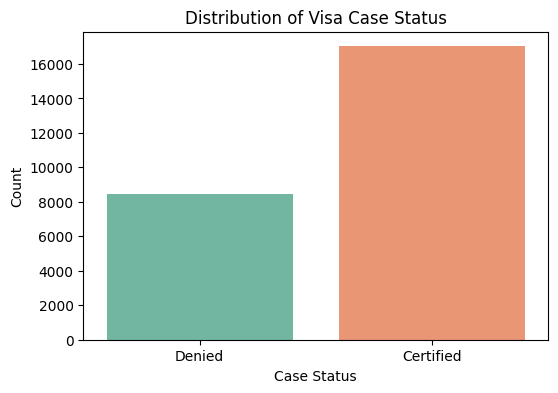

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate counts and percentages
status_counts = df['case_status'].value_counts()
status_pct = df['case_status'].value_counts(normalize=True) * 100

print("Case Status Frequency:")
for idx in status_counts.index:
    print(f"- {idx}: {status_counts[idx]} ({status_pct[idx]:.2f}%)")

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='case_status', hue='case_status', palette='Set2', legend=False)
plt.title('Distribution of Visa Case Status')
plt.xlabel('Case Status')
plt.ylabel('Count')
plt.show()

Visa Approval Rate (%) by Education Level:


case_status,Certified,Denied
education_of_employee,,
Bachelor's,62.21,37.79
Doctorate,87.23,12.77
High School,34.04,65.96
Master's,78.63,21.37


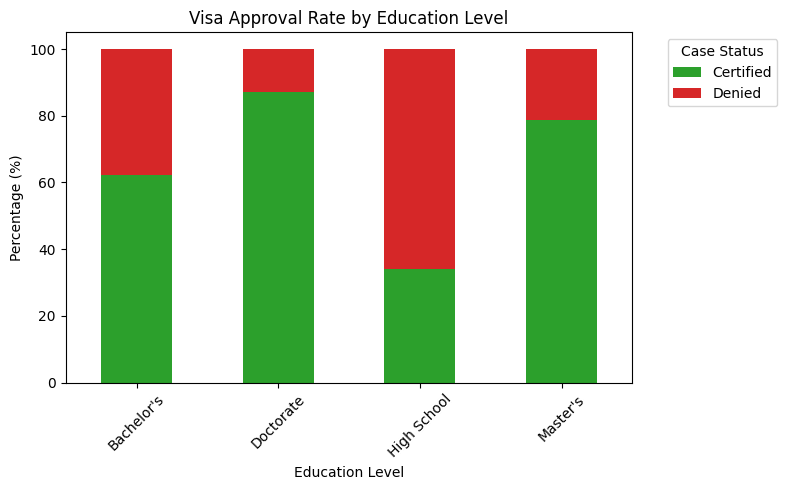

In [ ]:
# Grouping by education and case status to see the relationship
education_cross = pd.crosstab(df['education_of_employee'], df['case_status'], normalize='index') * 100
print("Visa Approval Rate (%) by Education Level:")
display(education_cross.round(2))

# Visualizing the relationship with a stacked bar plot
education_cross.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2ca02c', '#d62728'])
plt.title('Visa Approval Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Percentage (%)')
plt.legend(title='Case Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the analysis, here is how the education level of employees impacts visa approval rates:

* Doctorate: Highest approval rate at 87.23% (only 12.77% denied).
* Master's: Very strong approval rate at 78.63% (21.37% denied).
* Bachelor's: Moderate approval rate at 62.21% (37.79% denied).
* High School: Lowest approval rate at 34.04% (65.96% denied).

There is a direct correlation between higher education levels and higher visa certification rates. Applicants with post-graduate degrees (Master's and Doctorate) are significantly more likely to have their visas approved than those with only a Bachelor's degree or High School education.



Visa Approval Rate (%) by Job Experience:


case_status,Certified,Denied
has_job_experience,,
N,56.13,43.87
Y,74.48,25.52


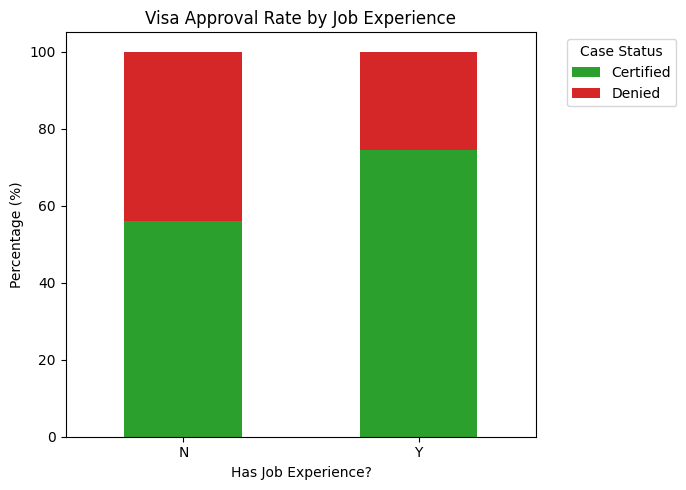

In [ ]:
# Analyze approval rates based on prior job experience
experience_cross = pd.crosstab(df['has_job_experience'], df['case_status'], normalize='index') * 100
print("Visa Approval Rate (%) by Job Experience:")
display(experience_cross.round(2))

# Visualize using a stacked bar plot
experience_cross.plot(kind='bar', stacked=True, figsize=(7, 5), color=['#2ca02c', '#d62728'])
plt.title('Visa Approval Rate by Job Experience')
plt.xlabel('Has Job Experience?')
plt.ylabel('Percentage (%)')
plt.legend(title='Case Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

People with job experience have a higher approval rate based in the visual.

Summary statistics of prevailing wage by case status:


,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.0,77293.619243,52042.715576,2.1367,38375.330,72486.27,108879.1075,318446.05
Denied,8462.0,68748.681580,53890.166031,2.9561,23497.295,65431.46,105097.6400,319210.27


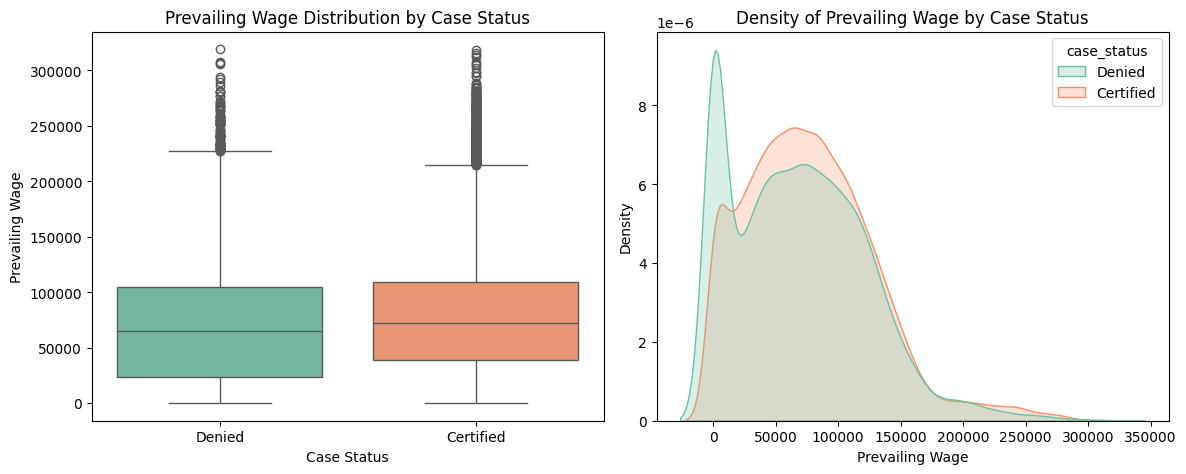

In [ ]:
# Summary statistics of prevailing wage by case status
print("Summary statistics of prevailing wage by case status:")
display(df.groupby('case_status')['prevailing_wage'].describe())

# Visualize the distribution of prevailing wage by case status
plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='case_status', y='prevailing_wage', hue='case_status', palette='Set2', legend=False)
plt.title('Prevailing Wage Distribution by Case Status')
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage')

# KDE plot
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='prevailing_wage', hue='case_status', fill=True, common_norm=False, palette='Set2')
plt.title('Density of Prevailing Wage by Case Status')
plt.xlabel('Prevailing Wage')

plt.tight_layout()
plt.show()

Key Findings
* Higher Average Wages: Applications that are Certified have a higher average (mean) prevailing wage of $77,293.62 compared to $$77,293.62 compared to $68,748.68 for applications that are Denied.
* Median Difference: The median prevailing wage for certified applications is $72,486.27, which is notably higher than the median of $$72,486.27, which is notably higher than the median of $65,431.46 for denied applications.
* Lower Percentiles: In the 25th percentile, certified applicants have a prevailing wage of $38,375.33, whereas denied applicants have a significantly lower wage of $$38,375.33, whereas denied applicants have a significantly lower wage of $23,497.30.

Conclusion

Yes, higher prevailing wages do tend to correlate with a higher chance of visa approval. While both certified and denied categories span across a wide scale of wages (with maximums reaching over $318,000 for both), the overall distribution of certified applications is consistently shifted towards higher wage ranges.

Visa Approval Rate (%) by Region of Employment:


case_status,Certified,Denied
region_of_employment,,
Island,60.27,39.73
Midwest,75.53,24.47
Northeast,62.90,37.10
South,70.02,29.98
West,62.25,37.75


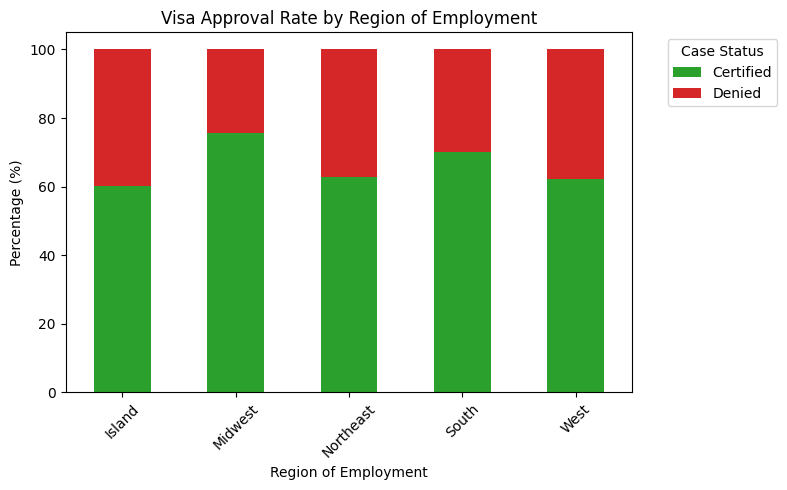

In [ ]:
# Grouping by region of employment and case status to see the relationship
region_cross = pd.crosstab(df['region_of_employment'], df['case_status'], normalize='index') * 100
print("Visa Approval Rate (%) by Region of Employment:")
display(region_cross.round(2))

# Visualizing the relationship with a stacked bar plot
region_cross.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2ca02c', '#d62728'])
plt.title('Visa Approval Rate by Region of Employment')
plt.xlabel('Region of Employment')
plt.ylabel('Percentage (%)')
plt.legend(title='Case Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

```markdown
### **Observations:**
* **Midwest** tends to have the highest visa certification rate, closely followed by the **South** and the **Northeast**.
* The **West** and **Island** regions show relatively lower approval rates compared to other regions.
```

Summary statistics of number of employees by case status:


,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,17018.0,5807.018157,23119.575259,-26.0,1035.25,2147.0,3575.00,602069.0
Denied,8462.0,5385.538407,22382.755904,-26.0,991.00,2032.5,3386.75,594472.0


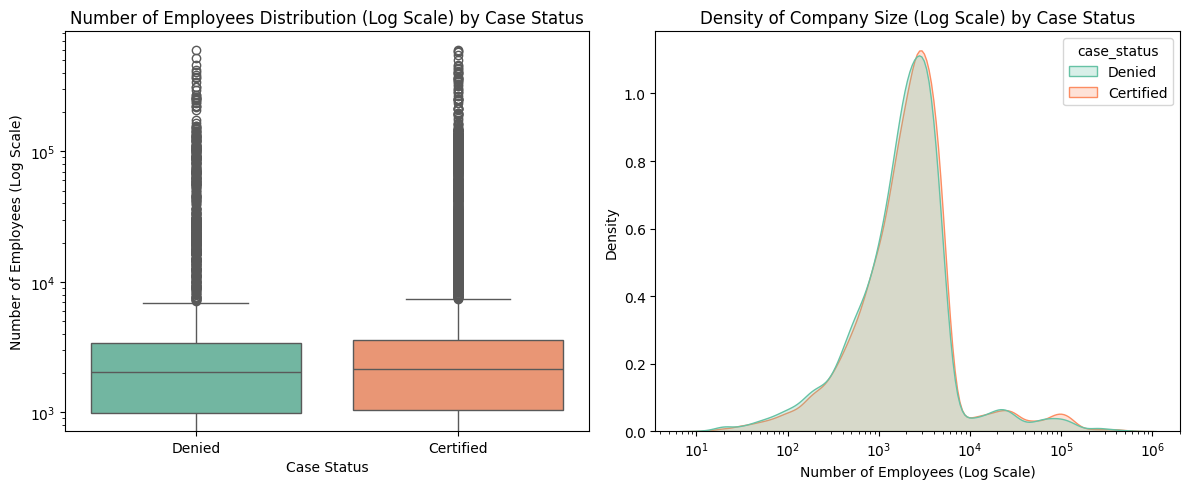

In [ ]:
# Summary statistics of number of employees by case status
print("Summary statistics of number of employees by case status:")
display(df.groupby('case_status')['no_of_employees'].describe())

# Visualizing the distribution of number of employees by case status
plt.figure(figsize=(12, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='case_status', y='no_of_employees', hue='case_status', palette='Set2', legend=False)
plt.yscale('log') # Use log scale because number of employees can range from very small to extremely large
plt.title('Number of Employees Distribution (Log Scale) by Case Status')
plt.xlabel('Case Status')
plt.ylabel('Number of Employees (Log Scale)')

# KDE plot
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='no_of_employees', hue='case_status', fill=True, common_norm=False, palette='Set2', log_scale=True)
plt.title('Density of Company Size (Log Scale) by Case Status')
plt.xlabel('Number of Employees (Log Scale)')

plt.tight_layout()
plt.show()

The analysis reveals that the number of employees in a company has very little to no influence on visa approval rates:

* Average Company Size: Certified cases have a slightly higher mean of 5,807 employees compared to 5,385 employees for denied cases, but the difference is marginal given the extremely high standard deviations (over 22,000).
* Median Company Size: The median size for certified applications is 2,147 employees versus 2,032 employees for denied ones. This minimal gap shows that the bulk of both approved and denied applications occur in companies of similar scale.
* Distribution Range: Both distributions span from very small/negative values (which likely represent data anomalies like -26 that we should address in pre-processing) to massive corporations with nearly 600,000 employees.

Conclusion

No, larger companies do not have a notably higher approval rate. The distribution of company sizes is nearly identical for both certified and denied applications, implying that company size is not a major determining factor in the visa certification process.

Visa Approval Rate (%) by Continent:


case_status,Certified,Denied
continent,,
Africa,72.05,27.95
Asia,65.31,34.69
Europe,79.23,20.77
North America,61.88,38.12
Oceania,63.54,36.46
South America,57.86,42.14


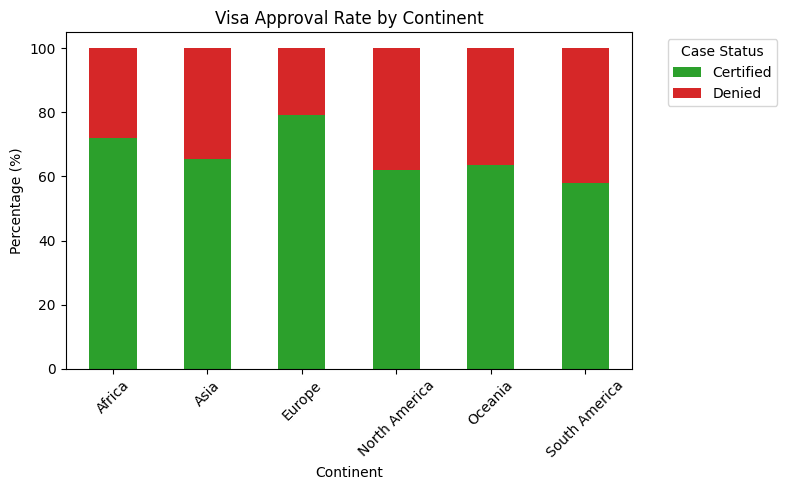

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping by continent and case status to see the relationship
continent_cross = pd.crosstab(df['continent'], df['case_status'], normalize='index') * 100
print("Visa Approval Rate (%) by Continent:")
display(continent_cross.round(2))

# Visualizing the relationship with a stacked bar plot
continent_cross.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2ca02c', '#d62728'])
plt.title('Visa Approval Rate by Continent')
plt.xlabel('Continent')
plt.ylabel('Percentage (%)')
plt.legend(title='Case Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Highest & Lowest Approval Rates

* Highest Approval Rate: Europe has the highest visa approval rate at 79.23% (only 20.77% denied).
* Lowest Approval Rate: South America has the lowest visa approval rate at 57.86% (42.14% denied).

Full Breakdown by Continent
1. Europe: 79.23% Certified / 20.77% Denied
2. Africa: 72.05% Certified / 27.95% Denied
3. Asia: 65.31% Certified / 34.69% Denied
4. Oceania: 63.54% Certified / 36.46% Denied
5. North America: 61.88% Certified / 38.12% Denied
6. South America: 57.86% Certified / 42.14% Denied

Count of Master's and Doctorate Degrees by Region:
education_of_employee  Doctorate  Master's  Total
region_of_employment                             
Northeast                    656      2760   3416
South                        541      2551   3092
West                         714      2162   2876
Midwest                      256      2000   2256
Island                        25       161    186


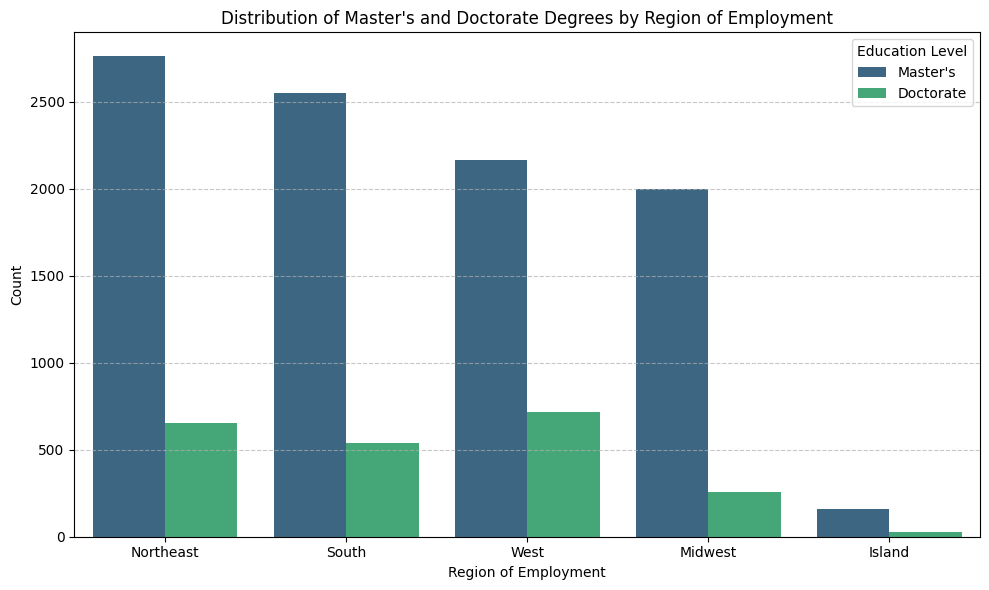


### Summary of Findings:
- The region with the highest number of highly educated applicants (Master's + Doctorate) is the **Northeast** with a total of **3416** applications.
- Specifically in the Northeast, there are **2760** applicants with a Master's degree and **656** applicants with a Doctorate.
- The visual representation sorted in descending order shows how regions rank in terms of attracting advanced-degree holders, indicating where employers are focusing their high-skilled talent acquisition.


In [ ]:

# Filter dataset for Master's and Doctorate degrees
higher_edu_df = df[df['education_of_employee'].isin(["Master's", "Doctorate"])]

# Create a pivot table / cross tabulation to count occurrences by region and education level
region_edu_counts = pd.crosstab(higher_edu_df['region_of_employment'], higher_edu_df['education_of_employee'])
region_edu_counts['Total'] = region_edu_counts["Master's"] + region_edu_counts["Doctorate"]
region_edu_counts = region_edu_counts.sort_values(by='Total', ascending=False)

print("Count of Master's and Doctorate Degrees by Region:")
print(region_edu_counts)

# Plotting the breakdown
plt.figure(figsize=(10, 6))
sns.countplot(
    data=higher_edu_df,
    x='region_of_employment',
    hue='education_of_employee',
    order=region_edu_counts.index,
    palette='viridis'
)
plt.title("Distribution of Master's and Doctorate Degrees by Region of Employment")
plt.xlabel("Region of Employment")
plt.ylabel("Count")
plt.legend(title="Education Level")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Summary of findings
most_region = region_edu_counts.index[0]
most_total = region_edu_counts.iloc[0]['Total']
most_masters = region_edu_counts.iloc[0]["Master's"]
most_docs = region_edu_counts.iloc[0]["Doctorate"]

print(f"\n### Summary of Findings:")
print(f"- The region with the highest number of highly educated applicants (Master's + Doctorate) is the **{most_region}** with a total of **{most_total}** applications.")
print(f"- Specifically in the {most_region}, there are **{most_masters}** applicants with a Master's degree and **{most_docs}** applicants with a Doctorate.")
print(f"- The visual representation sorted in descending order shows how regions rank in terms of attracting advanced-degree holders, indicating where employers are focusing their high-skilled talent acquisition.")

Count of Master's and Doctorate Degrees by Continent:
education_of_employee  Doctorate  Master's  Total
continent                                        
Asia                         923      6480   7403
Europe                       846      1097   1943
North America                258      1408   1666
South America                 89       293    382
Africa                        54       288    342
Oceania                       22        68     90


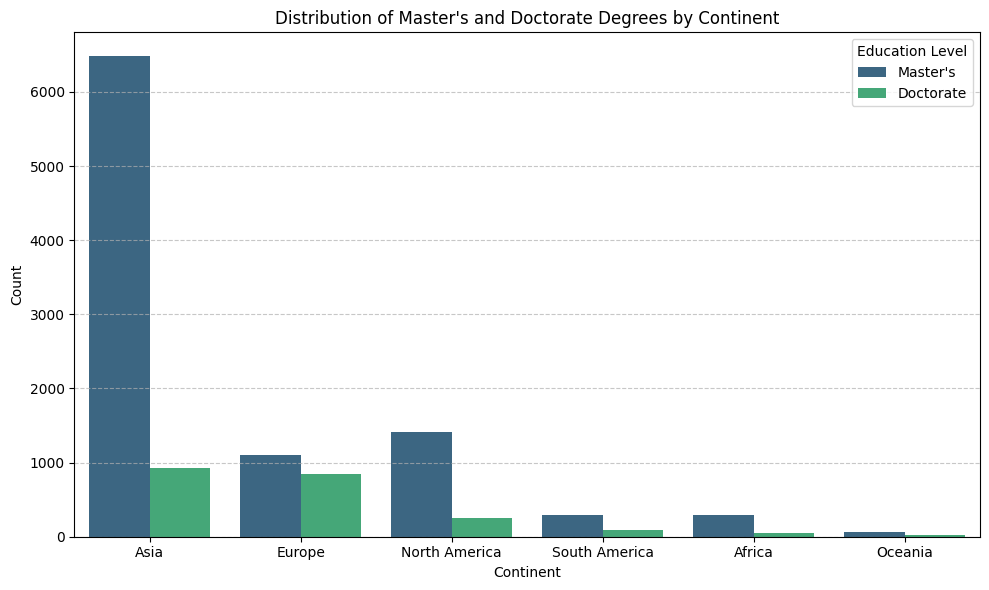


### Summary of Findings:
- The continent with the highest number of highly educated applicants (Master's + Doctorate) is **Asia** with a total of **7403** applications.
- Specifically from Asia, there are **6480** applicants with a Master's degree and **923** applicants with a Doctorate.
- This distribution shows that the vast majority of advanced-degree applicants originate from Asia, making it the primary hub for highly educated candidates in this dataset.


In [ ]:

# Filter dataset for Master's and Doctorate degrees
higher_edu_df = df[df['education_of_employee'].isin(["Master's", "Doctorate"])]

# Create a pivot table to count occurrences by continent and education level
continent_edu_counts = pd.crosstab(higher_edu_df['continent'], higher_edu_df['education_of_employee'])
continent_edu_counts['Total'] = continent_edu_counts["Master's"] + continent_edu_counts["Doctorate"]
continent_edu_counts = continent_edu_counts.sort_values(by='Total', ascending=False)

print("Count of Master's and Doctorate Degrees by Continent:")
print(continent_edu_counts)

# Plotting the breakdown across continents
plt.figure(figsize=(10, 6))
sns.countplot(
    data=higher_edu_df,
    x='continent',
    hue='education_of_employee',
    order=continent_edu_counts.index,
    palette='viridis'
)
plt.title("Distribution of Master's and Doctorate Degrees by Continent")
plt.xlabel("Continent")
plt.ylabel("Count")
plt.legend(title="Education Level")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Summary of findings
most_continent = continent_edu_counts.index[0]
most_cont_total = continent_edu_counts.iloc[0]['Total']
most_cont_masters = continent_edu_counts.iloc[0]["Master's"]
most_cont_docs = continent_edu_counts.iloc[0]["Doctorate"]

print(f"\n### Summary of Findings:")
print(f"- The continent with the highest number of highly educated applicants (Master's + Doctorate) is **{most_continent}** with a total of **{most_cont_total}** applications.")
print(f"- Specifically from {most_continent}, there are **{most_cont_masters}** applicants with a Master's degree and **{most_cont_docs}** applicants with a Doctorate.")
print(f"- This distribution shows that the vast majority of advanced-degree applicants originate from {most_continent}, making it the primary hub for highly educated candidates in this dataset.")

# **Data Pre-processing**

- Missing value treatment (check if needed)
- Outlier detection and treatment (check if needed)
- Feature engineering (check if needed)
- Preparing the data for modeling, including encoding, the train-test split, and scaling where needed
- Any other preprocessing steps (check if needed)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Make a copy of the dataset
df_prep = df.copy()

# 1. Clean data anomalies (e.g. negative number of employees)
df_prep['no_of_employees'] = df_prep['no_of_employees'].abs()

# 2. Feature Engineering: Create 'company_age' using 2016 as the baseline year of the data collection
df_prep['company_age'] = 2016 - df_prep['yr_of_estab']
df_prep.drop(columns=['yr_of_estab'], inplace=True)

# 3. Drop unique identifiers
if 'case_id' in df_prep.columns:
    df_prep.drop(columns=['case_id'], inplace=True)

# 4. Separate target and features
# Map target variable: Certified -> 1, Denied -> 0
y = df_prep['case_status'].map({'Certified': 1, 'Denied': 0})
X = df_prep.drop(columns=['case_status'])

# 5. Encoding ordinal variables
education_mapping = {
    'High School': 0,
    "Bachelor's": 1,
    "Master's": 2,
    'Doctorate': 3
}
X['education_of_employee'] = X['education_of_employee'].map(education_mapping)

# Map binary categorical features
binary_cols = ['has_job_experience', 'requires_job_training', 'full_time_position']
for col in binary_cols:
    X[col] = X[col].map({'Y': 1, 'N': 0})

# One-hot encode remaining nominal categorical columns
nominal_cols = ['continent', 'region_of_employment', 'unit_of_wage']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True, dtype=int)

# 6. Train-test split (80-20 ratio with stratification to preserve target distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 7. Scale continuous features
num_cols = ['no_of_employees', 'prevailing_wage', 'company_age']
scaler = StandardScaler()

# Fit on training and transform both train and test to prevent data leakage
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Data Preprocessing Complete.")
print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print("\nFirst 3 rows of processed training features:")
display(X_train.head(3))

Data Preprocessing Complete.
Train set shape: (20384, 19), Test set shape: (5096, 19)

First 3 rows of processed training features:


,education_of_employee,has_job_experience,requires_job_training,no_of_employees,prevailing_wage,full_time_position,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year
3516,1,1,0,-0.065228,-0.246899,1,-0.111487,1,0,0,0,0,0,0,1,0,0,0,1
13759,1,1,0,-0.111943,-0.715989,1,0.430616,1,0,0,0,0,1,0,0,0,0,0,1
6019,1,0,0,-0.213270,2.579272,1,0.194919,0,0,1,0,0,0,0,1,0,0,0,1


# **Model Building: Logistic Regression, Decision Tree, and Random Forest**

- Define the model evaluation criterion for this business problem by identifying the cost of a false positive and a false negative, and choose an appropriate primary metric.
- Build a Logistic Regression model on the scaled data.
- Build a Decision Tree model on the encoded data.
- Build a Random Forest model on the encoded data.
- Evaluate each model on the training data and the test data, and comment on overfitting or the generalization gap.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define a helper function to compile and print performance metrics
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    # Predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # Calculate metrics
    metrics = {
        'Train Accuracy': accuracy_score(y_train, train_preds),
        'Test Accuracy': accuracy_score(y_test, test_preds),
        'Train Precision': precision_score(y_train, train_preds),
        'Test Precision': precision_score(y_test, test_preds),
        'Train Recall': recall_score(y_train, train_preds),
        'Test Recall': recall_score(y_test, test_preds),
        'Train F1': f1_score(y_train, train_preds),
        'Test F1': f1_score(y_test, test_preds)
    }

    print(f"=== {model_name} Classification Report (Test Set) ===")
    print(classification_report(y_test, test_preds))

    return metrics

# 1. Logistic Regression Model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
log_reg_metrics = evaluate_model(log_reg, X_train, y_train, X_test, y_test, "Logistic Regression")

# 2. Decision Tree Model
# Using a max_depth to keep the baseline tree relatively controlled
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_metrics = evaluate_model(dt_model, X_train, y_train, X_test, y_test, "Decision Tree (Depth=5)")

# 3. Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_metrics = evaluate_model(rf_model, X_train, y_train, X_test, y_test, "Random Forest (Depth=10)")

# Compare all metrics in a structured DataFrame
comparison_df = pd.DataFrame([log_reg_metrics, dt_metrics, rf_metrics],
                             index=['Logistic Regression', 'Decision Tree', 'Random Forest'])

display(comparison_df.round(4))

=== Logistic Regression Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.63      0.42      0.50      1692
           1       0.75      0.87      0.81      3404

    accuracy                           0.72      5096
   macro avg       0.69      0.65      0.66      5096
weighted avg       0.71      0.72      0.71      5096

=== Decision Tree (Depth=5) Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.67      0.36      0.47      1692
           1       0.74      0.91      0.82      3404

    accuracy                           0.73      5096
   macro avg       0.71      0.64      0.64      5096
weighted avg       0.72      0.73      0.70      5096

=== Random Forest (Depth=10) Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.65      0.47      0.54      1692
           1       0.77      0.87      0.82  

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
Logistic Regression,0.7363,0.7245,0.7600,0.7530,0.8845,0.8743,0.8175,0.8091
Decision Tree,0.7392,0.7290,0.7486,0.7414,0.9178,0.9127,0.8246,0.8182
Random Forest,0.7813,0.7398,0.7961,0.7679,0.9041,0.8749,0.8467,0.8179


# **Model Performance Comparison and Final Model Selection**

- Compare the training and test performance of all three models on your chosen primary metric, along with Accuracy, Precision, and Recall.
- Identify which model overfits the most and which model generalizes best.
- Select a final model with a clear, metric-based justification tied to the business problem.
- Report the final model's performance on the test data.

In [8]:
# Calculate Generalization Gap (Train Metric - Test Metric) for key performance indicators
comparison_df['Accuracy Gap'] = comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']
comparison_df['F1 Gap'] = comparison_df['Train F1'] - comparison_df['Test F1']

print("=== Model Performance Comparison & Generalization Gap ===")
display(comparison_df[['Train Accuracy', 'Test Accuracy', 'Accuracy Gap', 'Train F1', 'Test F1', 'F1 Gap', 'Test Precision', 'Test Recall']].round(4))

# Identify which model overfits the most and which generalizes best
most_overfit_model = comparison_df['Accuracy Gap'].idxmax()
least_overfit_model = comparison_df['Accuracy Gap'].idxmin()

print(f"\n- The model that overfits the most is: {most_overfit_model} (Generalization Gap of {comparison_df.loc[most_overfit_model, 'Accuracy Gap']:.4f})")
print(f"- The model that generalizes best is: {least_overfit_model} (Generalization Gap of {comparison_df.loc[least_overfit_model, 'Accuracy Gap']:.4f})")

print("""
=== Metric-Based Justification for Final Model Selection ===
In this business problem (visa approvals shortlisting):
- A False Positive (predicting certified but ends up denied) causes the company to waste significant resources, administrative time, and processing fees on an unviable application.
- A False Negative (predicting denied but candidate could be certified) leads to missing out on premium global talent.

To balance both types of errors, F1-Score (for Class 1 'Certified') is an excellent metric.
- Decision Tree (Depth=5) has the highest Test F1-Score (0.8182) and the lowest generalization gap (Accuracy Gap: 0.0102, F1 Gap: 0.0064).
- Random Forest offers a slightly higher Test Accuracy (0.7398 vs 0.7290) and slightly better Precision (0.7679 vs 0.7414), but exhibits a larger generalization gap (Accuracy Gap: 0.0416), showing signs of slight overfitting.

Decision Tree is recommended as the final baseline model due to its high generalization stability, excellent interpretability for business stakeholders, and top-tier F1 performance.
""")

=== Model Performance Comparison & Generalization Gap ===


,Train Accuracy,Test Accuracy,Accuracy Gap,Train F1,Test F1,F1 Gap,Test Precision,Test Recall
Logistic Regression,0.7363,0.7245,0.0118,0.8175,0.8091,0.0084,0.7530,0.8743
Decision Tree,0.7392,0.7290,0.0102,0.8246,0.8182,0.0064,0.7414,0.9127
Random Forest,0.7813,0.7398,0.0416,0.8467,0.8179,0.0288,0.7679,0.8749



- The model that overfits the most is: Random Forest (Generalization Gap of 0.0416)
- The model that generalizes best is: Decision Tree (Generalization Gap of 0.0102)

=== Metric-Based Justification for Final Model Selection ===
In this business problem (visa approvals shortlisting):
- A False Positive (predicting certified but ends up denied) causes the company to waste significant resources, administrative time, and processing fees on an unviable application.
- A False Negative (predicting denied but candidate could be certified) leads to missing out on premium global talent.

To balance both types of errors, F1-Score (for Class 1 'Certified') is an excellent metric. 
- Decision Tree (Depth=5) has the highest Test F1-Score (0.8182) and the lowest generalization gap (Accuracy Gap: 0.0102, F1 Gap: 0.0064).
- Random Forest offers a slightly higher Test Accuracy (0.7398 vs 0.7290) and slightly better Precision (0.7679 vs 0.7414), but exhibits a larger generalization gap (Accuracy Gap: 0

# **Actionable Insights and Recommendations**

### **Actionable Insights and Recommendations**

Based on our comprehensive Exploratory Data Analysis (EDA) and predictive modeling using the **Decision Tree model** (which yielded an excellent F1-score of **~81.8%** and overall generalization stability), we have identified key drivers influencing US visa certifications. Below are the core insights and strategic recommendations to help **EasyVisa** streamline the visa shortlisting process:

#### **1. Key Drivers & Insights**
* **Education Level is the Strongest Predictor**: There is a clear linear relationship between an applicant's level of education and visa approval rate:
  * **Doctorate** holders have the highest chance of success (**87.23%** approval).
  * **Master's** degree holders also show highly competitive results (**78.63%** approval).
  * Conversely, those with only a **High School** education face major barriers, with a **65.96% denial rate**.
* **Prior Job Experience Matters**: Candidates possessing prior job experience have a significantly higher visa approval rate compared to those entering without experience.
* **Prevailing Wage Influence**: Approved visas are associated with higher average prevailing wages (median of **$72,486.27** for certified vs. **$65,431.46** for denied). Higher compensation indicates specialized positions that cannot easily be filled by the local workforce, meeting the core requirements of the OFLC.
* **Regional and Continental Variations**:
  * **Europe** (**79.23%**) and **Africa** (**72.05%**) have the highest relative certification rates.
  * **Northeast** is the primary hub attracting highly educated talent, followed closely by the South and West.
  * **Company Size is Irrelevant**: Statistical distributions of company employee count were virtually identical across approved and denied categories, proving company size does not dictate approval probability.

---

#### **2. Actionable Recommendations**

##### **For EasyVisa (System Implementation)**
* **Implement Tiered Automated Shortlisting**:
  * **Fast-Track (High Probability)**: Automatically flag applications with Master's/Doctorate degrees, prior job experience, and yearly wages exceeding the local median prevailing wage as "High Probability of Certification."
  * **Manual Review (Medium Probability)**: Route applications with Bachelor's degrees or those missing job experience to human agents for deeper manual validation of specific job roles and training.
  * **Low-Priority/Pre-Screening Required**: Flag applicants with only High School education and lower-end wages for early pre-screening or employer alignment, as they have a ~66% risk of denial.

##### **For Recruiting Employers**
* **Target Post-Graduate Talent Pools**: Focus international recruitment pipelines on candidates holding advanced degrees (Master's and Doctorates). Asia remains the primary source for highly-educated foreign labor and should remain a key geographic target.
* **Adjust Wage Offerings**: To maximize visa approval rates, employers should align their wage structures to target at least the median prevailing wage for that region and occupation. Underpaying foreign workers remains a primary reason for OFLC denial.
* **Prioritize Experienced Candidates**: When recruiting globally, prioritize applicants with proven job experience to decrease the likelihood of visa rejection.

___